In [1]:
import warnings
# warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import json
import pandas as pd

from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file,
)

from flonacomldft.free_energy_computations import (
    compute_BAR_from_samples, compute_TFP_from_samples
)
from ase.units import kB

beta = 1.0 / (kB * 350)
mode_labels = [0, 1]

### 0.1 - Dataframe with all the args of the simulations

In [2]:
# MARYLOU
project_path = '/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft'
subproject_path = project_path + '/adaptive-350/20231911_adaptive_single_isomer/'

os.listdir(subproject_path)

dic_args = {}

In [3]:
##### MD simulations
isomers = [0]*4 + [1]*4
flows_ids = [int('3006479{:d}'.format(i)) for i in range(8)]
samples_ids = [int('3006662{:d}'.format(i)) for i in range(8)]

subsubproject_path = subproject_path + '3-flows-md/'

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, flows_ids):
    args_file = 'args_train_flow_model_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-training'] = df_args

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, samples_ids):
    args_file = 'args_samples_from_flow_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-sampling'] = df_args


/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_31284/3194167661.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_31284/3194167661.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_31284/3194167661.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_31284/3194167661.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_

### 0.2 - Loading models

In [4]:
def load_models(isomer_id, process_id, project_path=subproject_path+ '/1-adaptive/'):
    if '3-flows-md' in project_path:
        f = 'is{:d}_flow_dic_{:d}.pkl'.format(isomer_id, process_id)
        models = [load_pickle_file(f, path=project_path)['model']]
    else:
        f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
        dic_trainings = load_pickle_file(f, path=project_path)
        models = [ dic[0]['model'] for dic in dic_trainings['dict_flows'] ]
    return models

In [5]:
def load_mlp_models(isomer_id, process_id, project_path=subproject_path+ '/1-adaptive/'):
    f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
    dic_trainings = load_pickle_file(f, path=project_path)
    mlp_models = [dic[0]['model']  for dic in dic_trainings['dict_mlps']]
    
    return mlp_models

### 0.3 - Loading the data

In [7]:
kinds = ['xs_adaptive', 'xs_proposals', 'MD-sampling']

# def load_samples_n_energies(kind, isomer_id, process_id, project_path=subproject_path + '/1-adaptive/'):
#     torch_tensor = load_csv_file('{:s}_is{:d}_{:d}.csv'.format(kind, isomer_id, process_id),
#                   path=project_path)
#     return torch_tensor[:, :12], torch_tensor[:, 12]

def load_samples_n_energies(kind, isomer_id, process_id, project_path=subproject_path + '/1-adaptive/'):
    if kind == 'xs_adaptive':
        torch_tensor = load_csv_file('{:s}_is{:d}_{:d}.csv'.format(kind, isomer_id, process_id),
                    path=project_path)
        xs = torch_tensor[:, :12]
        us = torch_tensor[:, 12]
    elif kind == 'MD-sampling':
        torch_tensor = load_csv_file('is{:d}_samples_rc_md_{:d}.csv'.format(isomer_id, process_id),
                    path=project_path)
        xs = torch_tensor[:, :12]
        us = torch_tensor[:, 12]
    elif kind == 'xs_proposals':
        # f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
        # dic_trainings = load_pickle_file(f, path=project_path)
        # xs = torch.stack(dic_trainings['xs_proposals']).reshape(-1, 12)
        # us = torch.stack(dic_trainings['us_proposals']).reshape(-1)
        torch_tensor = load_csv_file('is{:d}_proposals_xs_{:d}.csv'.format(isomer_id, process_id),
                    path=project_path)
        xs = torch_tensor[:, :12]
        us = torch_tensor[:, 12]

    return xs, us

In [56]:
"""
Script with Metropolis-Hasting algorithm. 

"""

import time
import numpy as np
import torch
import tqdm

from flonacomldft.collective_variables import get_collective_variables
# from ase.parallel import parprint as print
from ase.units import kB

#TODO: Add calculator for MLP
#TODO: Add cv values to return
#TODO: add docstrings

def run_metropolis(model, 
                    init, 
                    n_chains,
                    n_steps,
                    energy_type,
                    temperature,
                    mixture,
                    mlp_models=None,
                    frac_computed=0.2,
                    dim=12,
                    update_weights=True,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=False,
                    device='cpu',
                    folder_name=None,
                 ):

    assert init.shape[0] == n_chains

    if mixture:
        try:
            assert len(model.models) > 1
        except:
            raise RuntimeError("Model is not a mixture")
    
    print("Running Metropolis-Hastings")

    x_init = init[:, :dim]
    u_init = init[:, dim]
    isomer_init = init[:, dim+1]

    beta = 1 / (kB * temperature)

    print("Number of chains: {:d}".format(n_chains))
    print("Number of steps: {:d}".format(n_steps))
    print("Temperature: {:.1f}K".format(temperature))
    print("Energy Type: {:s}".format(energy_type))

    if "mlp" in energy_type:
        #TODO: Add calculator for MLP
        
        if (mlp_models is None):
            raise RuntimeError("No model to calculate energy")
        
        if mixture:
            print('Mixture model')
            model_mlp_is0, model_mlp_is1 = mlp_models
        else:
            if(isomer_init.sum()==0):
                model_mlp_is0 = mlp_models[0]
            else:
                model_mlp_is1 = mlp_models[0]
        
        print("Use Neural Predictor: True")
    
    else:
        
        print("No Neural Predictor")

    use_calc = False

    if return_ratios:
        ratios = []

    if return_proposals:
        xs_proposals = []
        us_proposals = []
        isomers_proposals = []
        nlls_proposals = []

    print("Mixture Model: {:s}".format(str(mixture)))

    if mixture:
        weights = [model.weights.clone().detach()]

    xs = []
    us = []
    accs = []
    isomers = []
    nlls = []

    time_step_mcmc = []

    if with_tqdm:
        pbar = tqdm.tqdm(range(n_steps))
    else:
        pbar = range(n_steps)
        print("Step \t Acc Rate")

    for dt in pbar:

        if mixture:
            x_new, isomer_new = model.sample(n_chains, return_mus=True)
        else:
            x_new = model.sample(n_chains)
            isomer_new = isomer_init.clone()

        x_new = x_new.clone().detach() #set float
        isomer_new = isomer_new.clone().detach() #set dype
        
        nll_x = model.nll(x_new)
        nll_x_init = model.nll(x_init)

        if return_proposals:
            xs_proposals.append(x_new.clone().detach())
            isomers_proposals.append(isomer_new.clone().detach())
            nlls_proposals.append(nll_x.clone().detach())

        if "mlp" in energy_type:

            u_new = torch.zeros((n_chains, 1)).squeeze()

            if mixture:
                u_new[~isomer_new.bool()] = model_mlp_is0(x_new[~isomer_new.bool()]).reshape(1, -1)
                u_new[isomer_new.bool()] = model_mlp_is1(x_new[isomer_new.bool()]).reshape(1, -1)

            else:
                if(isomer_new.sum()==0):
                    u_new = model_mlp_is0(x_new)
                else:
                    u_new = model_mlp_is1(x_new)

            u_new = u_new.squeeze()

        time_step_mcmc.append(time.time())

        if return_proposals:
            us_proposals.append(u_new.clone().detach())
        
        ratio = -beta * u_new + nll_x
        ratio += beta * u_init - nll_x_init
        ratio = torch.exp(ratio)

        if return_ratios:
            ratios.append( torch.min(ratio.clone().detach(), 
                            torch.ones_like(ratio)) )

        s = torch.rand_like(ratio)
        acc = s < torch.min(ratio.detach(), torch.ones_like(ratio))

        x_new[~acc] = x_init[~acc]
        u_new[~acc] = u_init[~acc]

        if mixture:
            isomer_new[~acc] = isomer_init[~acc]
        
        else:
            isomer_new = isomer_init.clone()
        
        xs.append(x_new.clone().detach())
        us.append(u_new.clone().detach())
        accs.append(acc.clone().detach())
        isomers.append(isomer_new.clone().detach())
        nlls.append(model.nll(x_new).clone().detach())

        x_init = x_new.clone().detach()
        u_init = u_new.clone().detach()
        isomer_init = isomer_new.clone().detach()

        if with_tqdm:
            pbar.set_description("Step {:d} \t Acceptance Rate {:.3f}".format(
                dt, acc.float().mean().item()))
        else:
            print("{:d} \t {:.3f}".format( dt, 
                                        acc.float().mean().item()
                                        )
            )

        if mixture and update_weights and dt > 0 and dt % scheduler_weights == 0:

            window_weights = torch.stack( [(~torch.stack(isomers).bool())[-scheduler_weights:].float().mean(),
                              torch.stack(isomers)[-scheduler_weights:].float().mean()] )

            new_weights = alpha * model.weights.clone() + (1 - alpha) * window_weights.clone()

            if torch.all(new_weights < 0.75):

                model.weights = new_weights.clone()

            weights.append(model.weights.clone().detach())

    to_return = {
        'xs': torch.stack(xs),
        'us': torch.stack(us),
        'accs': torch.stack(accs),
        'isomers': torch.stack(isomers),
        'nlls': torch.stack(nlls),
        'time_mcmc': time_step_mcmc,
    }

    if return_ratios:
        to_return['ratios'] = torch.stack(ratios)

    if return_proposals:
        to_return['xs_proposals'] = torch.stack(xs_proposals)
        to_return['us_proposals'] = torch.stack(us_proposals)
        to_return['isomers_proposals'] = torch.stack(isomers_proposals)
        to_return['nlls_proposals'] = torch.stack(nlls_proposals)

    if use_calc:
            
        to_return['xs_calc'] = torch.stack(xs_calc)
        to_return['us_calc'] = torch.stack(us_calc)
        to_return['isomers_calc'] = torch.stack(isomers_calc)
        to_return['inds_calc'] = torch.stack(inds_calc)

    if mixture and update_weights:
        to_return['weights'] = torch.stack(weights)

    return to_return


### 0.z - Inspecting the models

#### 0.z.3 - MD only

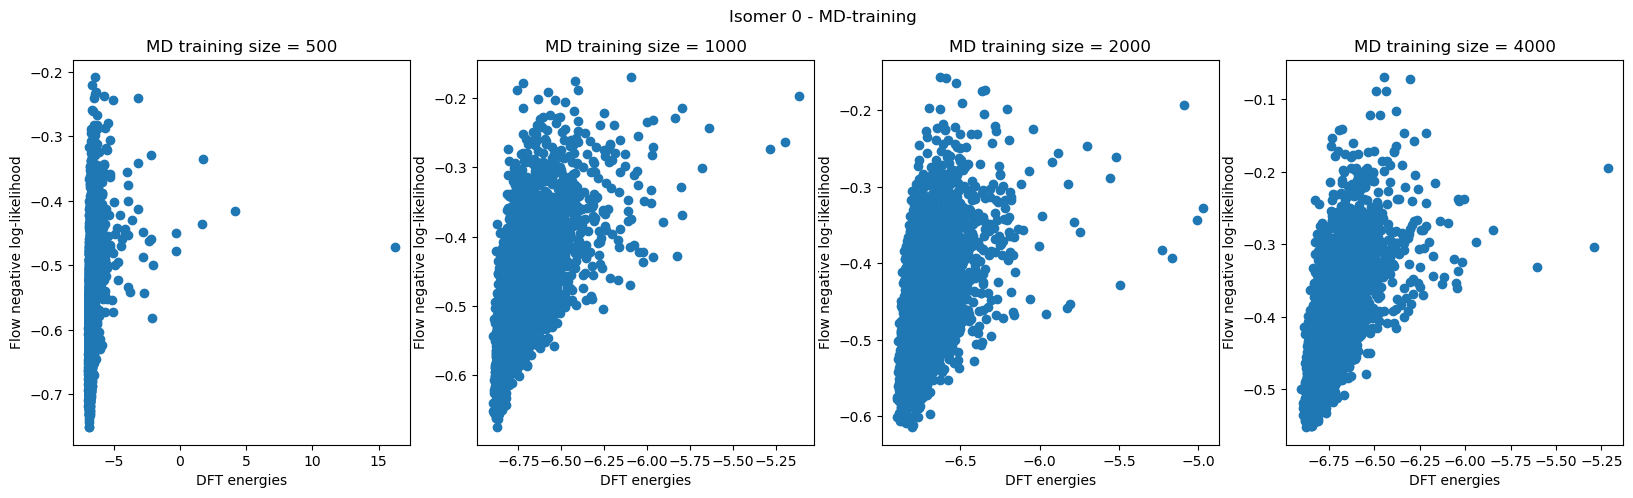

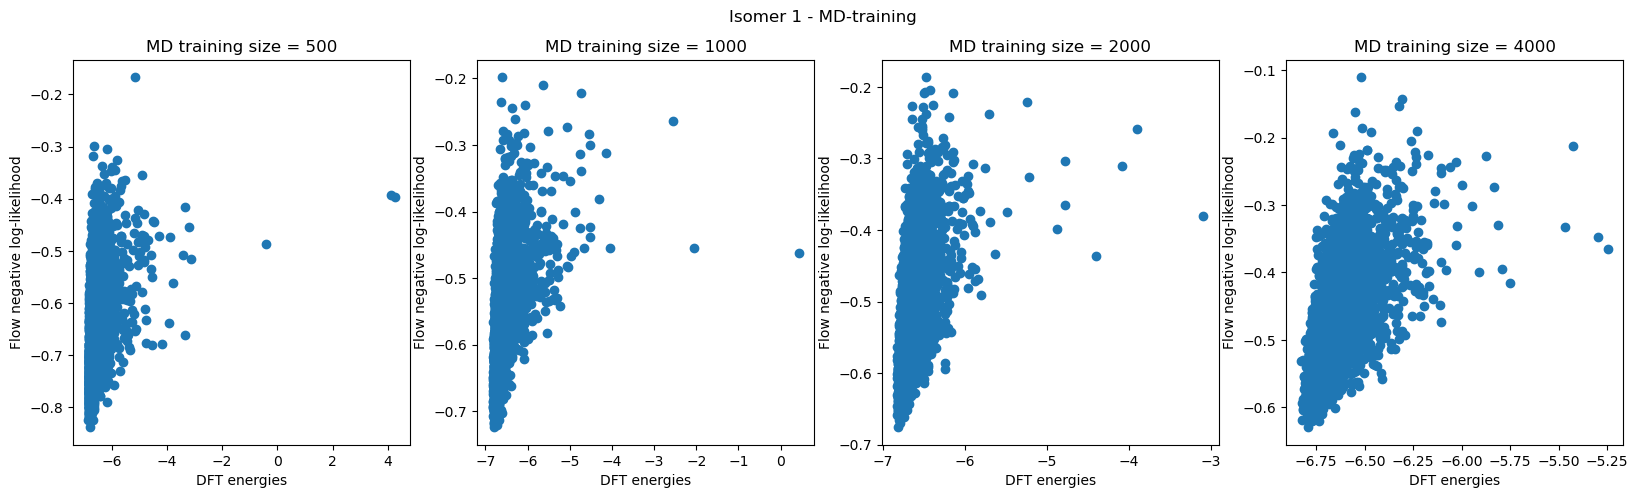

In [10]:
kind = 'MD-training'
df_args = dic_args[kind]

df_args_sample = dic_args['MD-sampling']

for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id)]
    df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values
    samples_ids = df_isomer_sample['process_id'].values

    plt.figure(figsize=(5 * 4 / 1, 5 * 1))
    plt.suptitle('Isomer {:d} - {:s}'.format(isomer_id, kind))
    axs = [plt.subplot(1, int(4 // 1), i+1) for i in range(4)]
    ax_ = 0

    for md_training_size, process_id, samples_id in zip(md_training_sizes, process_ids, samples_ids):

        models = load_models(isomer_id, process_id, project_path=subproject_path + '/3-flows-md/') 

        prop_samples, energy_target = load_samples_n_energies('MD-sampling', isomer_id, samples_id, project_path=subproject_path + '/3-flows-md/')
        # mc_samples, mc_energy_target = load_samples_n_energies('xs_adaptive', isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
            
        logprob_prop = (- models[0].nll(prop_samples)).detach().numpy()
        logprob_target = (- beta * energy_target).detach().numpy()
    
        plt.sca(axs[ax_])
        plt.scatter( - logprob_target / beta, - logprob_prop / beta)
        plt.xlabel('DFT energies')
        plt.ylabel('Flow negative log-likelihood')
        plt.title('MD training size = {:d}'.format(md_training_size))

        ax_ += 1

### Reconstructing the training/test datasets

In [12]:
path_datasets = subproject_path + 'database/andersen/datasets'
md_training_sizes = [500, 1000, 2000, 4000]

dim = 12

dic_md_training_datasets = {}

for isomer_id in mode_labels:
    dic_md_training_datasets[isomer_id] = {}

    for N in md_training_sizes:
        dic_md_training_datasets[isomer_id][N] = {}

        print('N = {:d}'.format(N))
    
        data = load_csv_file('is{:d}_{:s}_train.csv'.format(mode_labels[isomer_id], 'flow'),
                      path=path_datasets)[:N, :dim+2]

        # train_md, test_md = list(split_data_from_dataframe(data, 0.8, sk_seed=42))
        # dic_md_training_datasets[isomer_id][N]['train'] = train_md
        # dic_md_training_datasets[isomer_id][N]['test'] = test_md
        dic_md_training_datasets[isomer_id][N] = data 

N = 500
N = 1000
N = 2000
N = 4000
N = 500
N = 1000
N = 2000
N = 4000


# Metropolis-Hasting on isomer 0

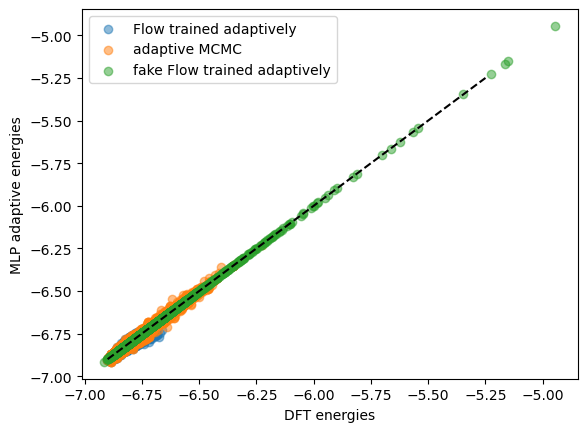

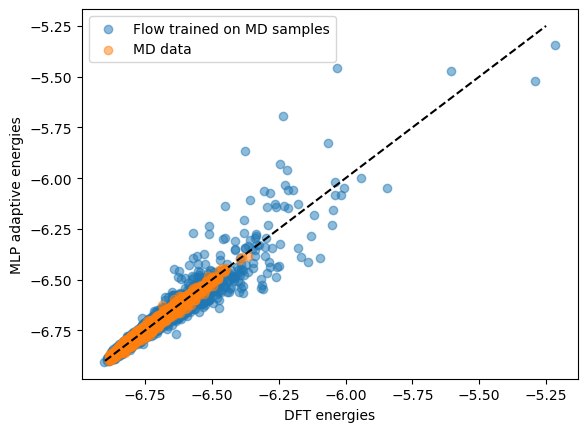

In [78]:
kind = 'MD-training'
batch_size = 1000 ## best trainings to be selected - not necessarily everywhere
df_args = dic_args[kind]

df_args_sample = dic_args['MD-sampling']

md_training_sizes = [500, 1000, 2000, 4000]

isomer_id = 0
md_training_size = 4000

df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]
df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id) & (df_args['N'] == md_training_size)]

### Loading an mlp model trained on the dft data

process_id_mlp = 30019623 ## adaptive with 4000 initial MD samples ISO 0
# process_id_mlp = 30019627 ## adaptive with 4000 initial MD samples ISO 1
mlp_models = load_mlp_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')
flow_model_adaptive = load_models(isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')[-1]
prop_samples_adaptive, prop_energy_target_adaptive = load_samples_n_energies('xs_proposals', isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')
fake_prop_samples_adaptive = flow_model_adaptive.sample(prop_samples_adaptive.shape[0])
fake_prop_energy_target_adaptive = mlp_models[0](fake_prop_samples_adaptive).detach().numpy()
mc_samples_adaptive, mc_energy_target_adaptive = load_samples_n_energies('xs_adaptive', isomer_id, process_id_mlp, project_path=subproject_path + '/2-adaptive-mlp/')


plt.figure()
plt.scatter(prop_energy_target_adaptive, mlp_models[0](prop_samples_adaptive).detach().numpy(), alpha=0.5, label='Flow trained adaptively')
plt.scatter(mc_energy_target_adaptive, mlp_models[0](mc_samples_adaptive).detach().numpy(), alpha=0.5, label='adaptive MCMC')
plt.scatter(fake_prop_energy_target_adaptive, mlp_models[0](fake_prop_samples_adaptive).detach().numpy(), alpha=0.5, label='fake Flow trained adaptively')
plt.plot([-6.9, -5.25], [-6.9, -5.25], 'k--')
plt.xlabel('DFT energies')
plt.ylabel('MLP adaptive energies')
plt.legend()

###
process_id_flow = df_isomer['process_id'].values[0]
samples_id = df_isomer_sample['process_id'].values[0]
prop_samples, prop_energy_target = load_samples_n_energies('MD-sampling', isomer_id, samples_id, project_path=subproject_path + '/3-flows-md/')
train_sample, train_energy_target = dic_md_training_datasets[isomer_id][md_training_size][:, :12], dic_md_training_datasets[isomer_id][md_training_size][:, 12]

plt.figure()
plt.scatter(prop_energy_target, mlp_models[0](prop_samples).detach().numpy(), alpha=0.5, label='Flow trained on MD samples')
plt.scatter(train_energy_target, mlp_models[0](train_sample).detach().numpy(), alpha=0.5, label='MD data')
plt.plot([-6.9, -5.25], [-6.9, -5.25], 'k--')
plt.xlabel('DFT energies')
plt.ylabel('MLP adaptive energies')
plt.legend()


In [73]:
prop_samples_adaptive.shape

torch.Size([9000, 12])

In [ ]:
###
flow_model_md = load_models(isomer_id, process_id_flow, project_path=subproject_path + '/3-flows-md/')[0]

mixture = False
update_weights = False
temperature = 350
energy_type = 'mlp'

n_chains = 100

init = flow_model_md.sample(n_chains)
init = torch.cat([init, mlp_models[0](init), torch.zeros((n_chains, 1)) + isomer_id], dim=1)
n_steps = 500

to_return_md_flow = run_metropolis(flow_model_md, init, n_chains, n_steps, energy_type,
                    temperature,
                    mixture,
                    mlp_models=mlp_models,
                    frac_computed=0.2,
                    dim=12,
                    update_weights=update_weights,
                    scheduler_weights=10,
                    alpha=0.5,
                    return_ratios=True,
                    return_proposals=True,
                    with_tqdm=True,
                    device='cpu',
                    folder_name=None,
                 )

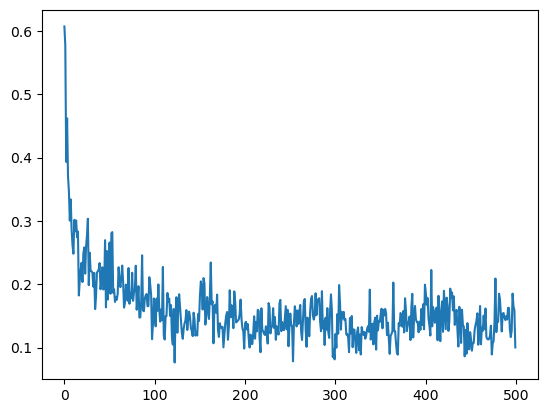

In [69]:
accs = to_return_md_flow['accs']
ratios = to_return_md_flow['ratios']

plt.plot(torch.mean(ratios, dim=1))

In [54]:
init[:,13]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], grad_fn=<SelectBackward0>)